# VFA-1 — Linear Function Approximation Experiment

Trains a `LinearFAAgent` on a 10×10 `FogGridWorld` for 5 000 episodes and compares
it directly against a `TabularQAgent` trained on the **same** sequence of random maps.

**Scientific question:** does linear FA generalise better than tabular Q-learning
when every episode presents a fresh random layout?

This notebook covers:
1. Training both agents
2. Learning-curve comparison
3. Learned-weight interpretation

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / 'src' / 'environment').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.environment.grid_world import FogGridWorld
from src.agents.tabular_q import TabularQAgent
from src.agents.linear_fa import LinearFAAgent
from src.features.feature_extractor import N_FEATURES

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Train both agents

Both agents train on the **same** environment object so they encounter identical
random map sequences (seeded by NumPy's default RNG).
Each episode resets with a fresh random layout — memorisation is impossible.

Hyperparameters follow the VFA-1 design spec:
- Tabular: `alpha=0.1` (higher — table entries are independent)
- Linear FA: `alpha=0.01` (lower — a single theta update affects *all* states)

In [2]:
N_TRAIN = 5000
GRID    = 10
SMOOTH  = 50   # rolling-average window for learning curves

env = FogGridWorld(grid_size=GRID)

# ── Tabular Q-Learning ────────────────────────────────────────────────────────
agent_q = TabularQAgent(
    n_actions     = env.action_space.n,
    alpha         = 0.1,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.995,
)

q_rewards:   list[float] = []
q_table_sizes: list[int] = []

for ep in range(1, N_TRAIN + 1):
    obs, _ = env.reset()
    ep_reward = 0.0
    done = False

    while not done:
        action = agent_q.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent_q.update(obs, action, reward, next_obs, terminated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated

    agent_q.decay_epsilon()
    q_rewards.append(ep_reward)
    q_table_sizes.append(agent_q.q_table_size)

    if ep % 1000 == 0:
        avg = float(np.mean(q_rewards[-100:]))
        print(
            f'[Tabular] ep {ep:>5}  '
            f'avg_reward(100) {avg:+.3f}  '
            f'eps {agent_q.epsilon:.3f}  '
            f'Q-entries {agent_q.q_table_size:,}'
        )

[Tabular] ep  1000  avg_reward(100) -2.087  eps 0.050  Q-entries 273,919
[Tabular] ep  2000  avg_reward(100) -2.063  eps 0.050  Q-entries 553,987
[Tabular] ep  3000  avg_reward(100) -1.925  eps 0.050  Q-entries 838,740
[Tabular] ep  4000  avg_reward(100) -1.815  eps 0.050  Q-entries 1,111,227
[Tabular] ep  5000  avg_reward(100) -1.891  eps 0.050  Q-entries 1,386,331


In [3]:
# ── Linear Function Approximation ─────────────────────────────────────────────
agent_fa = LinearFAAgent(
    n_actions     = env.action_space.n,
    max_steps     = env.max_steps,
    alpha         = 0.01,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.995,
)

fa_rewards: list[float] = []

for ep in range(1, N_TRAIN + 1):
    obs, _ = env.reset()
    ep_reward = 0.0
    done = False

    while not done:
        action = agent_fa.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent_fa.update(obs, action, reward, next_obs, terminated, truncated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated

    agent_fa.decay_epsilon()
    fa_rewards.append(ep_reward)

    if ep % 1000 == 0:
        avg = float(np.mean(fa_rewards[-100:]))
        print(
            f'[Linear FA] ep {ep:>5}  '
            f'avg_reward(100) {avg:+.3f}  '
            f'eps {agent_fa.epsilon:.3f}  '
            f'theta {np.round(agent_fa.theta, 3)}'
        )

[Linear FA] ep  1000  avg_reward(100) +0.539  eps 0.050  theta [-0.271 -0.83   0.314  0.103 -0.341]
[Linear FA] ep  2000  avg_reward(100) +0.677  eps 0.050  theta [-0.382 -0.935  0.424  0.167 -0.286]
[Linear FA] ep  3000  avg_reward(100) +0.667  eps 0.050  theta [-0.307 -1.026  0.42   0.251 -0.318]
[Linear FA] ep  4000  avg_reward(100) +0.529  eps 0.050  theta [-0.307 -1.047  0.325  0.143 -0.398]
[Linear FA] ep  5000  avg_reward(100) +0.698  eps 0.050  theta [-0.394 -1.059  0.311  0.229 -0.344]


## 2. Learning-curve comparison

Both curves are smoothed with a 50-episode rolling average.

**Expected pattern:**
- Tabular Q plateaus or degrades as the Q-table fills with state-specific entries
  that never generalise to new map layouts.
- Linear FA converges to a higher (less negative) average reward because `phi(s, a)`
  encodes structure that transfers across episodes: wall proximity, goal visibility,
  energy level.

The bottom panel shows the explosive growth of the tabular Q-table — a direct proxy
for the curse of dimensionality.

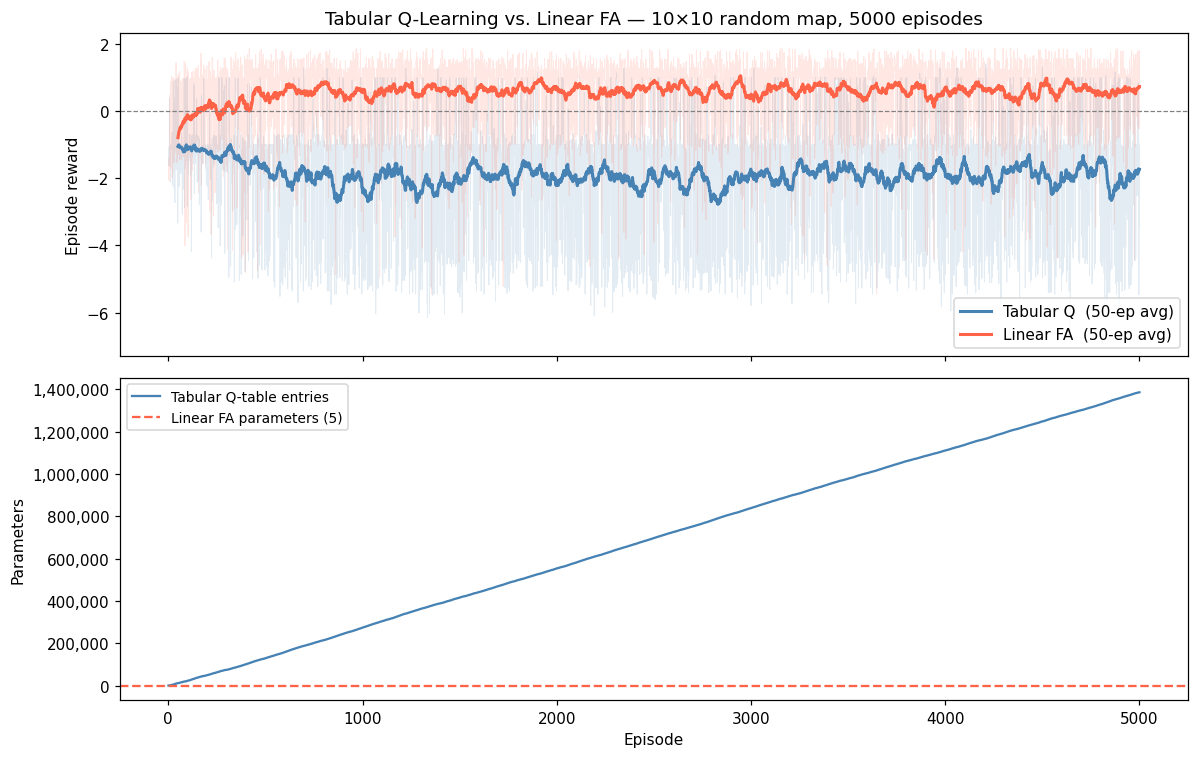

Tabular  last-100 avg reward: -1.8913
Linear FA last-100 avg reward: +0.6981
Tabular Q-table entries: 1,386,331
Linear FA parameters:    5


In [4]:
episodes = np.arange(1, N_TRAIN + 1)
kernel   = np.ones(SMOOTH) / SMOOTH

q_smooth  = np.convolve(q_rewards,  kernel, mode='valid')
fa_smooth = np.convolve(fa_rewards, kernel, mode='valid')
x_smooth  = episodes[SMOOTH - 1:]

fig, (ax_r, ax_q) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# ── Reward panel ──────────────────────────────────────────────────────────────
ax_r.plot(episodes, q_rewards,
          alpha=0.15, color='steelblue', linewidth=0.6)
ax_r.plot(episodes, fa_rewards,
          alpha=0.15, color='tomato', linewidth=0.6)
ax_r.plot(x_smooth, q_smooth,
          color='steelblue', linewidth=2.0, label=f'Tabular Q  ({SMOOTH}-ep avg)')
ax_r.plot(x_smooth, fa_smooth,
          color='tomato',    linewidth=2.0, label=f'Linear FA  ({SMOOTH}-ep avg)')
ax_r.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_r.set_ylabel('Episode reward')
ax_r.legend(loc='lower right', fontsize=10)
ax_r.set_title(
    f'Tabular Q-Learning vs. Linear FA — {GRID}×{GRID} random map, {N_TRAIN} episodes',
    fontsize=12,
)

# ── Q-table size panel ────────────────────────────────────────────────────────
ax_q.plot(episodes, q_table_sizes, color='steelblue', linewidth=1.5,
          label='Tabular Q-table entries')
ax_q.axhline(N_FEATURES, color='tomato', linewidth=1.5, linestyle='--',
             label=f'Linear FA parameters ({N_FEATURES})')
ax_q.set_ylabel('Parameters')
ax_q.set_xlabel('Episode')
ax_q.legend(fontsize=9)
ax_q.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

print(f'Tabular  last-100 avg reward: {float(np.mean(q_rewards[-100:])):+.4f}')
print(f'Linear FA last-100 avg reward: {float(np.mean(fa_rewards[-100:])):+.4f}')
print(f'Tabular Q-table entries: {agent_q.q_table_size:,}')
print(f'Linear FA parameters:    {N_FEATURES}')

## 3. Learned weight interpretation

Linear FA converges to a weight vector `theta` that is interpretable by construction.

| Index | Feature             | Expected sign | Interpretation |
|-------|---------------------|---------------|----------------|
| 0     | `wall_ahead`        | −             | Blocking actions lead to wall-bump penalties |
| 1     | `goal_visible`      | +             | Seeing the goal signals high nearby return |
| 2     | `energy_level`      | −             | More energy = more −0.01 step costs ahead |
| 3     | `energy_pickup_vis` | +             | A visible pickup extends the episode |
| 4     | `step_progress`     | −             | Further into the episode = fewer future returns |

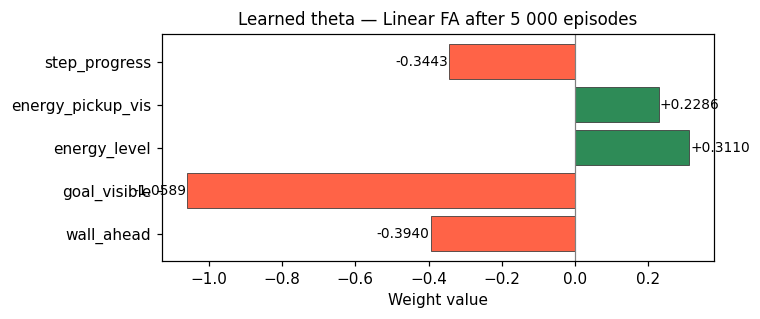

In [5]:
feature_names = [
    'wall_ahead',
    'goal_visible',
    'energy_level',
    'energy_pickup_vis',
    'step_progress',
]

theta = agent_fa.weights
colors = ['tomato' if w < 0 else 'seagreen' for w in theta]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(feature_names, theta, color=colors, edgecolor='#333', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Weight value')
ax.set_title('Learned theta — Linear FA after 5 000 episodes', fontsize=11)
for bar, val in zip(bars, theta):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
    )
plt.tight_layout()
plt.show()

---

## 4. Tabular Q: Fixed Map vs. Random Map

Reproduces the PowerPoint comparison slide.

| Experiment | Grid | Episodes | `fixed_map` |
|------------|------|----------|-------------|
| Fixed Map  | 10×10 | 2 000  | `True` — same layout every episode |
| Random Map | 10×10 | 5 000  | `False` — fresh layout every episode |

**Expected result:**
- Fixed map → agent memorises the layout → reward converges to +1.0 (goal)
- Random map → every episode produces unseen states → Q-table grows indefinitely, no convergence

Fixed   last-100 avg: +1.029  |  37,656 entries
Random  last-100 avg: -1.852  |  1,387,307 entries


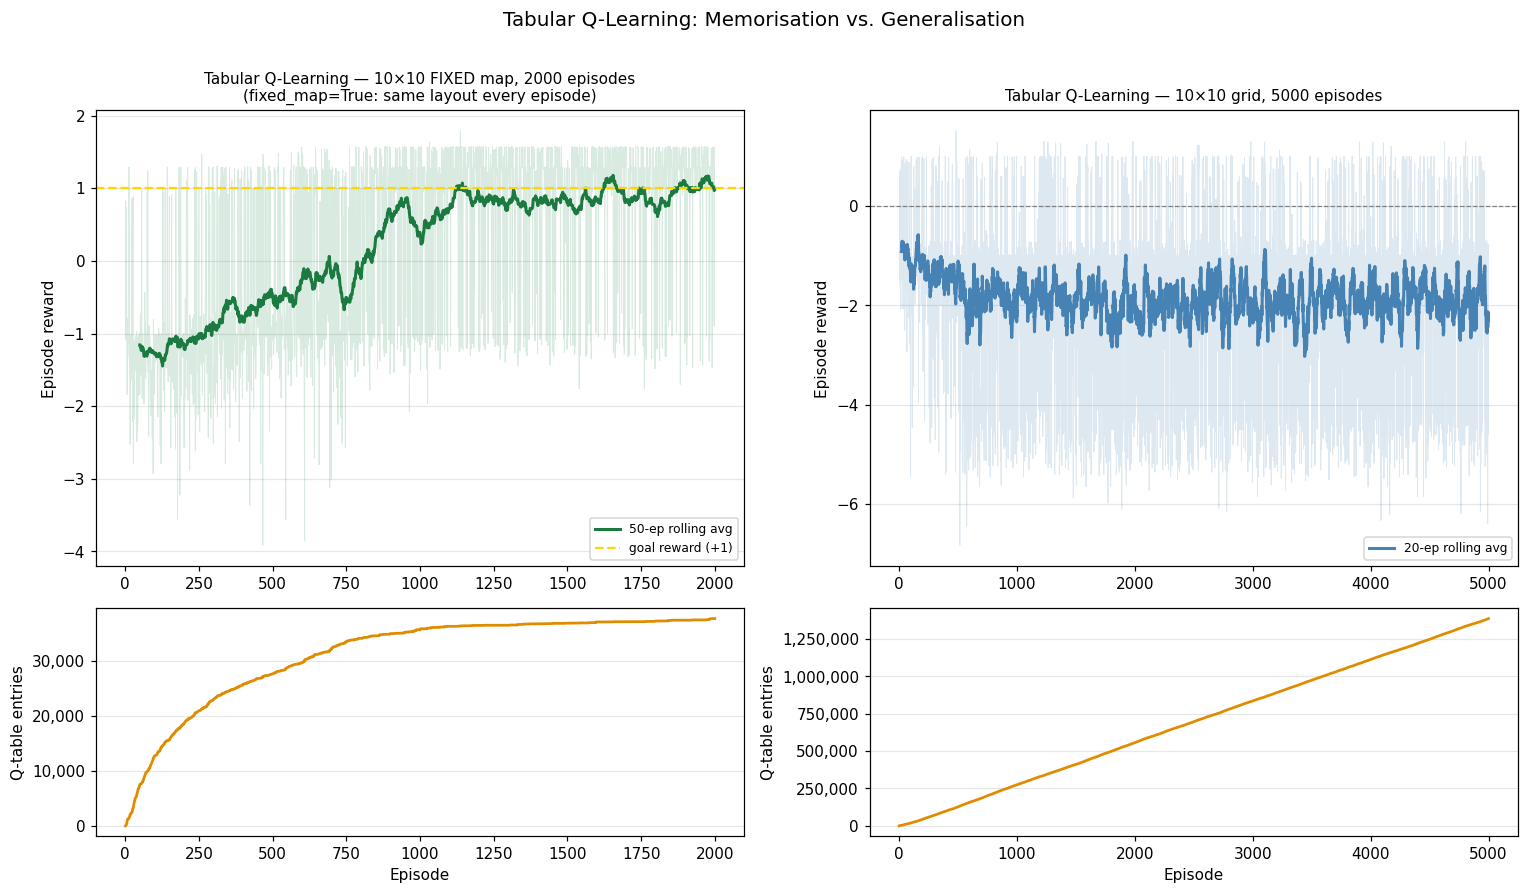

Saved → tabular_fixed_vs_random.png


In [6]:
# ── Config ────────────────────────────────────────────────────────────────────
GRID_SLIDE   = 10
N_FIXED      = 2_000
N_RANDOM     = 5_000
SMOOTH_FIXED = 50
SMOOTH_RAND  = 20

# ── Fixed-map experiment ──────────────────────────────────────────────────────
env_fixed = FogGridWorld(grid_size=GRID_SLIDE, fixed_map=True)
aq_fixed  = TabularQAgent(
    n_actions=env_fixed.action_space.n,
    alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
)

fixed_rewards:     list[float] = []
fixed_table_sizes: list[int]   = []

for ep in range(1, N_FIXED + 1):
    obs, _ = env_fixed.reset()
    ep_reward, done = 0.0, False
    while not done:
        action = aq_fixed.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env_fixed.step(action)
        aq_fixed.update(obs, action, reward, next_obs, terminated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated
    aq_fixed.decay_epsilon()
    fixed_rewards.append(ep_reward)
    fixed_table_sizes.append(aq_fixed.q_table_size)

print(f'Fixed   last-100 avg: {np.mean(fixed_rewards[-100:]):+.3f}  |  {aq_fixed.q_table_size:,} entries')

# ── Random-map experiment ─────────────────────────────────────────────────────
env_rand = FogGridWorld(grid_size=GRID_SLIDE, fixed_map=False)
aq_rand  = TabularQAgent(
    n_actions=env_rand.action_space.n,
    alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
)

rand_rewards:     list[float] = []
rand_table_sizes: list[int]   = []

for ep in range(1, N_RANDOM + 1):
    obs, _ = env_rand.reset()
    ep_reward, done = 0.0, False
    while not done:
        action = aq_rand.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env_rand.step(action)
        aq_rand.update(obs, action, reward, next_obs, terminated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated
    aq_rand.decay_epsilon()
    rand_rewards.append(ep_reward)
    rand_table_sizes.append(aq_rand.q_table_size)

print(f'Random  last-100 avg: {np.mean(rand_rewards[-100:]):+.3f}  |  {aq_rand.q_table_size:,} entries')

# ── Side-by-side plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [2, 1]})
(ax_fr, ax_rr), (ax_fq, ax_rq) = axes

def _smooth(data, w):
    return np.convolve(data, np.ones(w) / w, mode='valid')

# ── Left column: Fixed map ────────────────────────────────────────────────────
eps_f = np.arange(1, N_FIXED + 1)
ax_fr.plot(eps_f, fixed_rewards,
           alpha=0.18, color='seagreen', linewidth=0.6)
ax_fr.plot(eps_f[SMOOTH_FIXED - 1:], _smooth(fixed_rewards, SMOOTH_FIXED),
           color='#1a7a40', linewidth=2.0,
           label=f'{SMOOTH_FIXED}-ep rolling avg')
ax_fr.axhline(1.0, color='gold', linewidth=1.5, linestyle='--',
              label='goal reward (+1)')
ax_fr.set_ylabel('Episode reward')
ax_fr.set_title(
    f'Tabular Q-Learning — {GRID_SLIDE}×{GRID_SLIDE} FIXED map, {N_FIXED} episodes\n'
    f'(fixed_map=True: same layout every episode)',
    fontsize=10,
)
ax_fr.legend(fontsize=8, loc='lower right')
ax_fr.grid(axis='y', alpha=0.3)

ax_fq.plot(eps_f, fixed_table_sizes, color='#e08c00', linewidth=1.8)
ax_fq.set_ylabel('Q-table entries')
ax_fq.set_xlabel('Episode')
ax_fq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_fq.grid(axis='y', alpha=0.3)

# ── Right column: Random map ──────────────────────────────────────────────────
eps_r = np.arange(1, N_RANDOM + 1)
ax_rr.plot(eps_r, rand_rewards,
           alpha=0.18, color='steelblue', linewidth=0.6)
ax_rr.plot(eps_r[SMOOTH_RAND - 1:], _smooth(rand_rewards, SMOOTH_RAND),
           color='steelblue', linewidth=2.0,
           label=f'{SMOOTH_RAND}-ep rolling avg')
ax_rr.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax_rr.set_ylabel('Episode reward')
ax_rr.set_title(
    f'Tabular Q-Learning — {GRID_SLIDE}×{GRID_SLIDE} grid, {N_RANDOM} episodes',
    fontsize=10,
)
ax_rr.legend(fontsize=8, loc='lower right')
ax_rr.grid(axis='y', alpha=0.3)

ax_rq.plot(eps_r, rand_table_sizes, color='#e08c00', linewidth=1.8)
ax_rq.set_ylabel('Q-table entries')
ax_rq.set_xlabel('Episode')
ax_rq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_rq.grid(axis='y', alpha=0.3)

plt.suptitle('Tabular Q-Learning: Memorisation vs. Generalisation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('tabular_fixed_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → tabular_fixed_vs_random.png')

---

## 5. Linear FA: Fixed Map vs. Random Map

Same comparison — but with **Linear FA** instead of Tabular Q.

| Experiment | Grid | Episodes | `fixed_map` |
|------------|------|----------|-------------|
| Fixed Map  | 10×10 | 2 000  | `True` — same layout every episode |
| Random Map | 10×10 | 5 000  | `False` — fresh layout every episode |

**Expected result:**
- Fixed map → FA learns useful features → reward converges (similar to tabular, via generalisation)
- Random map → FA **generalises** across layouts → reward stabilises, weight norm converges  
  (contrast: tabular Q-table grew indefinitely on random maps)

FA Fixed   last-100 avg: -0.364  theta=[-0.099 -0.977  0.138 -0.029 -0.446]
FA Random  last-100 avg: +0.693  theta=[-0.381 -1.055  0.318  0.225 -0.305]


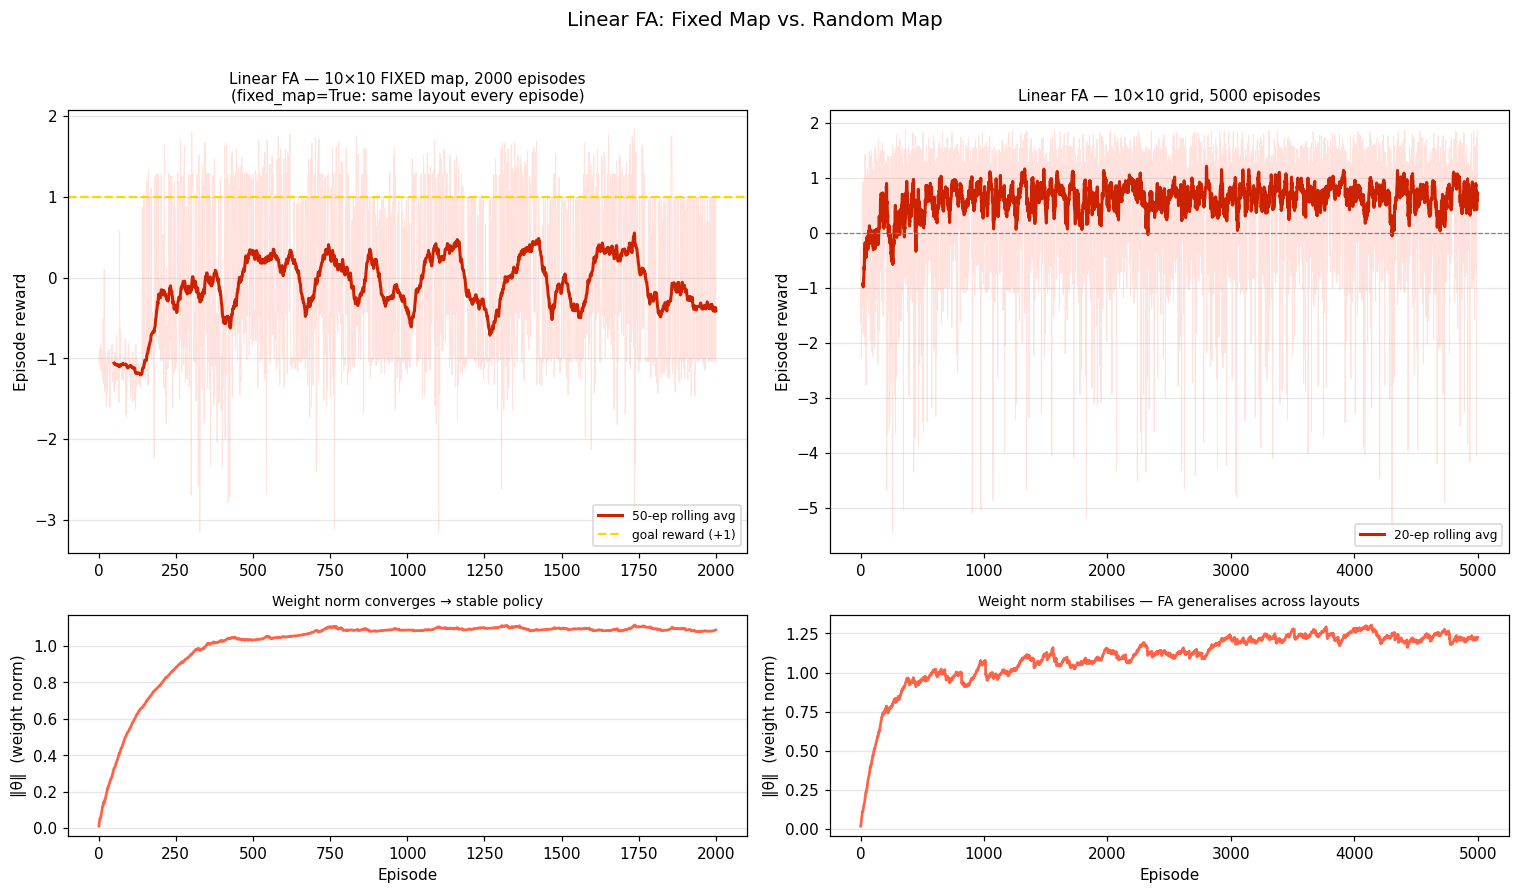

Saved → fa_fixed_vs_random.png


In [7]:
from src.features.feature_extractor import SimpleFeatureExtractor

_FA_GRID   = 10
_N_FIXED   = 2_000
_N_RANDOM  = 5_000
_SW_FIXED  = 50
_SW_RAND   = 20

def _run_fa(fixed_map: bool, n_episodes: int):
    env = FogGridWorld(grid_size=_FA_GRID, fixed_map=fixed_map)
    agent = LinearFAAgent(
        n_actions=env.action_space.n,
        max_steps=env.max_steps,
        alpha=0.01, gamma=0.99,
        epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
    )
    rewards, theta_norms = [], []
    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset()
        ep_reward, done = 0.0, False
        while not done:
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            agent.update(obs, action, reward, next_obs, terminated, truncated)
            obs = next_obs
            ep_reward += reward
            done = terminated or truncated
        agent.decay_epsilon()
        rewards.append(ep_reward)
        theta_norms.append(float(np.linalg.norm(agent.theta)))
    return rewards, theta_norms, agent

fa_fixed_rewards,  fa_fixed_norms,  fa_fixed_agent  = _run_fa(fixed_map=True,  n_episodes=_N_FIXED)
fa_random_rewards, fa_random_norms, fa_random_agent = _run_fa(fixed_map=False, n_episodes=_N_RANDOM)

print(f'FA Fixed   last-100 avg: {np.mean(fa_fixed_rewards[-100:]):+.3f}  theta={np.round(fa_fixed_agent.theta, 3)}')
print(f'FA Random  last-100 avg: {np.mean(fa_random_rewards[-100:]):+.3f}  theta={np.round(fa_random_agent.theta, 3)}')

# ── Plot ──────────────────────────────────────────────────────────────────────
def _smooth(data, w):
    return np.convolve(data, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [2, 1]})
(ax_fr, ax_rr), (ax_fn, ax_rn) = axes

# ── Left: Fixed map ───────────────────────────────────────────────────────────
eps_f = np.arange(1, _N_FIXED + 1)
ax_fr.plot(eps_f, fa_fixed_rewards, alpha=0.18, color='tomato', linewidth=0.6)
ax_fr.plot(eps_f[_SW_FIXED - 1:], _smooth(fa_fixed_rewards, _SW_FIXED),
           color='#cc2200', linewidth=2.0, label=f'{_SW_FIXED}-ep rolling avg')
ax_fr.axhline(1.0, color='gold', linewidth=1.5, linestyle='--', label='goal reward (+1)')
ax_fr.set_ylabel('Episode reward')
ax_fr.set_title(
    f'Linear FA — {_FA_GRID}×{_FA_GRID} FIXED map, {_N_FIXED} episodes\n'
    f'(fixed_map=True: same layout every episode)',
    fontsize=10,
)
ax_fr.legend(fontsize=8, loc='lower right')
ax_fr.grid(axis='y', alpha=0.3)

ax_fn.plot(eps_f, fa_fixed_norms, color='tomato', linewidth=1.8)
ax_fn.set_ylabel('‖θ‖  (weight norm)')
ax_fn.set_xlabel('Episode')
ax_fn.set_title('Weight norm converges → stable policy', fontsize=9)
ax_fn.grid(axis='y', alpha=0.3)

# ── Right: Random map ─────────────────────────────────────────────────────────
eps_r = np.arange(1, _N_RANDOM + 1)
ax_rr.plot(eps_r, fa_random_rewards, alpha=0.18, color='tomato', linewidth=0.6)
ax_rr.plot(eps_r[_SW_RAND - 1:], _smooth(fa_random_rewards, _SW_RAND),
           color='#cc2200', linewidth=2.0, label=f'{_SW_RAND}-ep rolling avg')
ax_rr.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax_rr.set_ylabel('Episode reward')
ax_rr.set_title(
    f'Linear FA — {_FA_GRID}×{_FA_GRID} grid, {_N_RANDOM} episodes',
    fontsize=10,
)
ax_rr.legend(fontsize=8, loc='lower right')
ax_rr.grid(axis='y', alpha=0.3)

ax_rn.plot(eps_r, fa_random_norms, color='tomato', linewidth=1.8)
ax_rn.set_ylabel('‖θ‖  (weight norm)')
ax_rn.set_xlabel('Episode')
ax_rn.set_title('Weight norm stabilises — FA generalises across layouts', fontsize=9)
ax_rn.grid(axis='y', alpha=0.3)

plt.suptitle('Linear FA: Fixed Map vs. Random Map', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fa_fixed_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fa_fixed_vs_random.png')